# Mount Google Drive and Import Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random
import zipfile

Mounted at /content/drive


# Define Dataset Paths and Check File Availability

In [3]:
import os

BASE_PATH = "/content/drive/MyDrive/DriveGuard"

ZIP_PATH = os.path.join(BASE_PATH, "all_cams_ds_driveguard_spatial_roi.zip")

# נחלץ מקומית בקולאב, לא לדרייב
DATASET_PATH = "/content/all_cams_ds_driveguard_spatial_roi"

print("ZIP exists:", os.path.exists(ZIP_PATH))
print("Dataset folder exists:", os.path.exists(DATASET_PATH))

ZIP exists: True
Dataset folder exists: False


# Extract Dataset from ZIP to Colab Local Storage

In [5]:
import zipfile
import os

if not os.path.exists(DATASET_PATH):
    print("Extracting dataset to Colab local storage...")
    os.makedirs(DATASET_PATH, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_PATH)

    print("Extraction completed.")
else:
    print("Dataset already extracted.")

Extracting dataset to Colab local storage...
Extraction completed.


# Verify Extracted Dataset Structure

In [6]:
print("Dataset path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))
print("Content:")
print(os.listdir(DATASET_PATH))

Dataset path: /content/all_cams_ds_driveguard_spatial_roi
Exists: True
Content:
['ds_driveguard_spatial_roi']


# Set Final Dataset Path and Inspect Train/Val/Test Folders

In [7]:
DATASET_PATH = "/content/all_cams_ds_driveguard_spatial_roi/ds_driveguard_spatial_roi"

print("Dataset path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))
print("Folders inside:")
print(os.listdir(DATASET_PATH))

Dataset path: /content/all_cams_ds_driveguard_spatial_roi/ds_driveguard_spatial_roi
Exists: True
Folders inside:
['val', 'train', 'test']


# Inspect Class Labels in Train, Validation, and Test Sets

In [8]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASET_PATH, split)

    print("\nSplit:", split)
    print("Exists:", os.path.exists(split_path))
    print("Folders/classes:", os.listdir(split_path))


Split: train
Exists: True
Folders/classes: ['Phone', 'Drink', 'Safe']

Split: val
Exists: True
Folders/classes: ['Phone', 'Drink', 'Safe']

Split: test
Exists: True
Folders/classes: ['Phone', 'Drink', 'Safe']


# Count Images in Each Class and Dataset Split

In [9]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

rows = []

for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASET_PATH, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = 0
            for root, dirs, files in os.walk(class_path):
                count += sum(file.lower().endswith(image_extensions) for file in files)

            rows.append({
                "split": split,
                "class": class_name,
                "num_images": count
            })

df_counts = pd.DataFrame(rows)
df_counts

,split,class,num_images
0,train,Phone,8025
1,train,Drink,11640
2,train,Safe,10835
3,val,Phone,1905
4,val,Drink,3150
5,val,Safe,1720
6,test,Phone,2520
7,test,Drink,4905
8,test,Safe,3880


# Build a DataFrame with All Image Paths and Labels

In [10]:
all_images = []

for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASET_PATH, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            for root, dirs, files in os.walk(class_path):
                for file in files:
                    if file.lower().endswith(image_extensions):
                        all_images.append({
                            "path": os.path.join(root, file),
                            "split": split,
                            "label": class_name
                        })

df_images = pd.DataFrame(all_images)

print("Total images:", len(df_images))
df_images.head()

Total images: 48580


,path,split,label
0,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone
1,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone
2,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone
3,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone
4,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone


# Display Random Sample Images from the Dataset

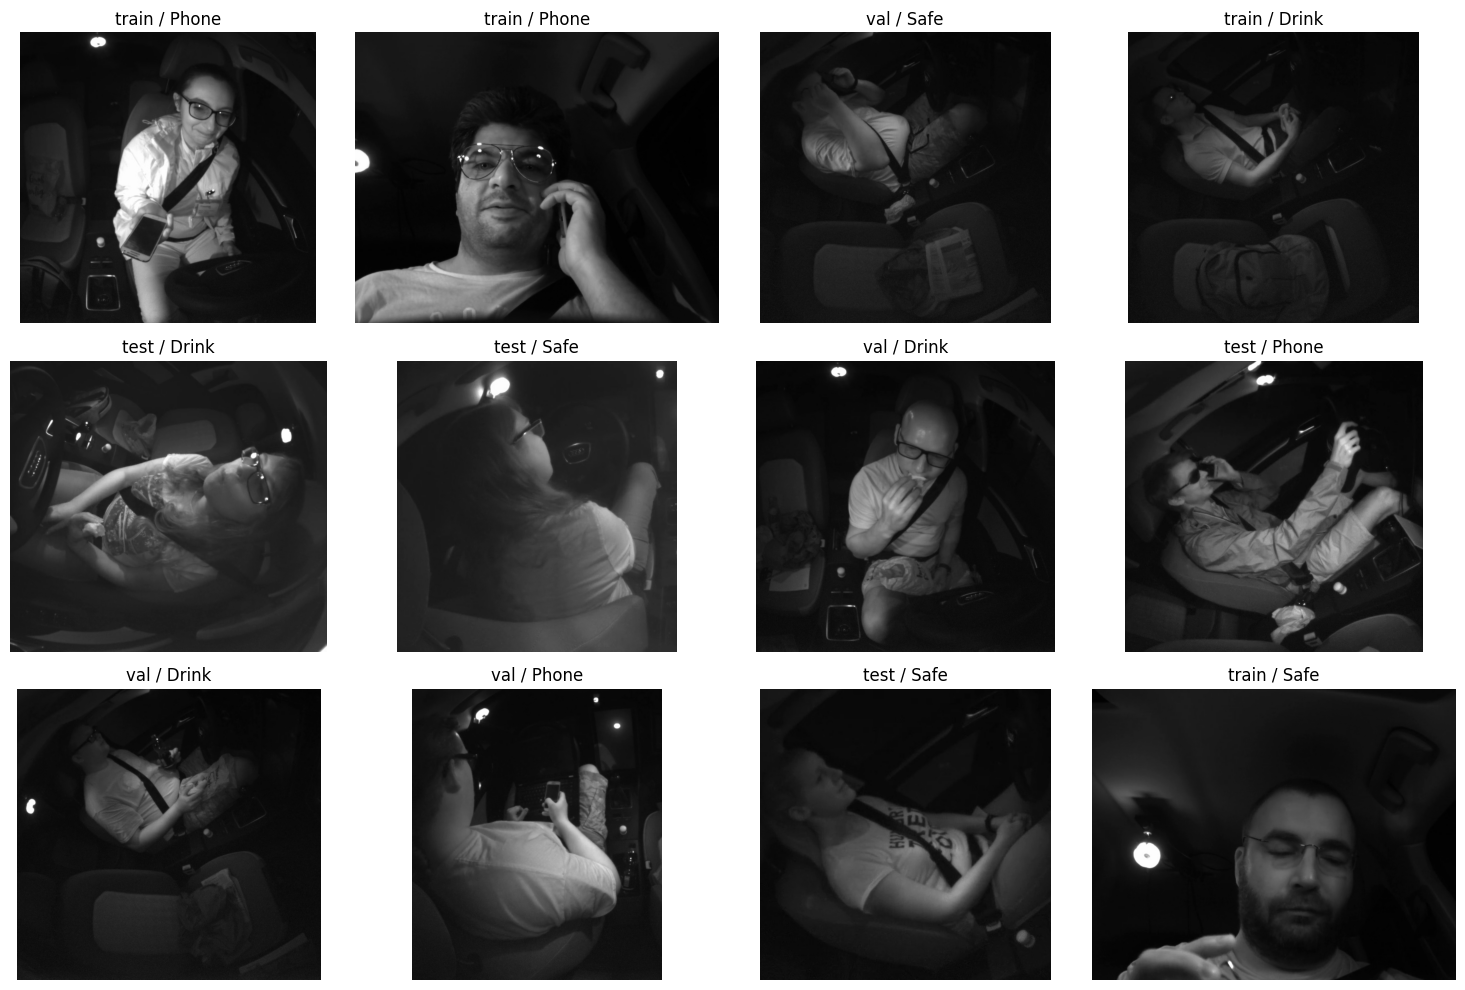

In [11]:
sample_df = df_images.sample(12, random_state=42)

plt.figure(figsize=(15, 10))

for i, row in enumerate(sample_df.itertuples()):
    img = Image.open(row.path).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"{row.split} / {row.label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Install Ultralytics and Load the YOLO Pose Model

In [12]:
!pip install ultralytics -q

from ultralytics import YOLO

pose_model = YOLO("yolo11n-pose.pt")
print("YOLO Pose loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO Pose loaded successfully.


# Visualize YOLO Pose Predictions on Sample Images

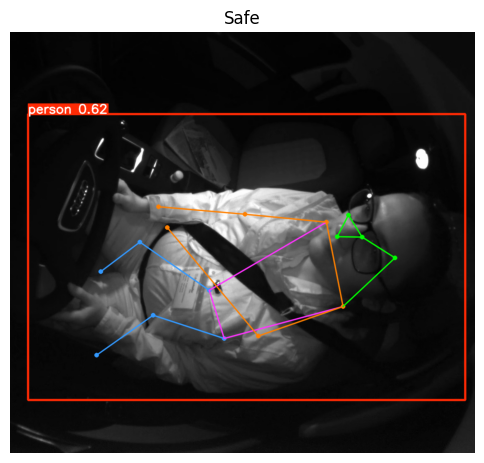

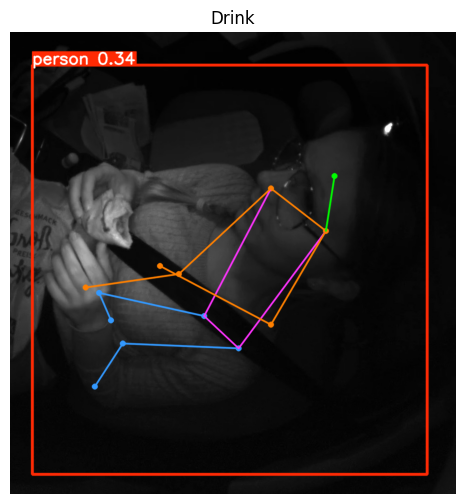

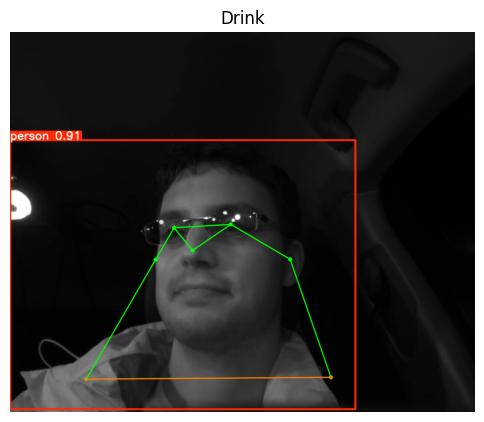

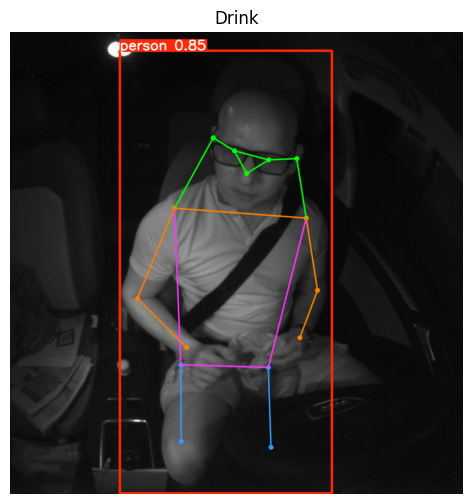

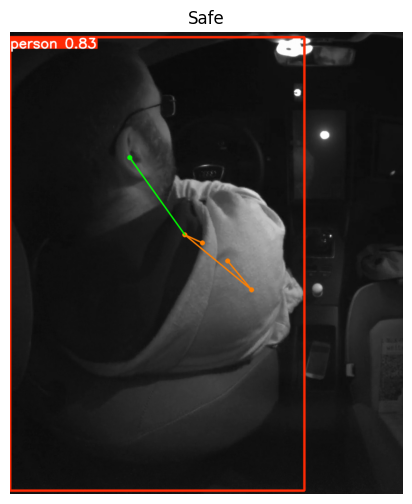

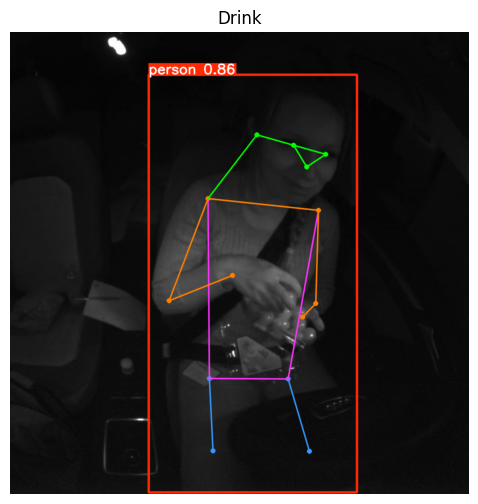

In [13]:
sample_df = df_images.sample(6, random_state=7)

for row in sample_df.itertuples():
    results = pose_model(row.path, verbose=False)
    plotted = results[0].plot()

    plt.figure(figsize=(6, 6))
    plt.imshow(plotted)
    plt.title(row.label)
    plt.axis("off")
    plt.show()

# Evaluate YOLO Pose Detection Rate on 100 Random Images

In [14]:
sample_df = df_images.sample(100, random_state=10)

detected = 0
not_detected = 0

for row in sample_df.itertuples():
    results = pose_model(row.path, verbose=False)
    keypoints = results[0].keypoints

    if keypoints is None or keypoints.xy is None or len(keypoints.xy) == 0:
        not_detected += 1
    else:
        detected += 1

print("Detected:", detected)
print("Not detected:", not_detected)
print("Detection rate:", detected / len(sample_df))

Detected: 100
Not detected: 0
Detection rate: 1.0


# Extract Keypoints and Confidence Scores from an Image

In [25]:
import numpy as np

def extract_keypoints_from_image(image_path):
    results = pose_model(image_path, verbose=False)
    keypoints = results[0].keypoints

    if keypoints is None or keypoints.xy is None or len(keypoints.xy) == 0:
        return None, None

    xy = keypoints.xy[0].cpu().numpy()      # נקודות בפיקסלים
    conf = keypoints.conf[0].cpu().numpy()  # רמת ביטחון לכל נקודה

    return xy, conf

# Define Geometric Feature Extraction Functions

In [26]:
def distance(p1, p2):
    return np.linalg.norm(p1 - p2)

def angle(a, b, c):
    ba = a - b
    bc = c - b

    if np.linalg.norm(ba) == 0 or np.linalg.norm(bc) == 0:
        return 0

    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    cos_angle = np.clip(cos_angle, -1, 1)

    return np.degrees(np.arccos(cos_angle))

def keypoints_to_features(kp, conf):
    # keypoints indexes
    nose = kp[0]
    l_eye = kp[1]
    r_eye = kp[2]
    l_ear = kp[3]
    r_ear = kp[4]
    l_shoulder = kp[5]
    r_shoulder = kp[6]
    l_elbow = kp[7]
    r_elbow = kp[8]
    l_wrist = kp[9]
    r_wrist = kp[10]
    l_hip = kp[11]
    r_hip = kp[12]

    shoulder_width = distance(l_shoulder, r_shoulder)
    if shoulder_width == 0:
        shoulder_width = 1

    torso_height = distance((l_shoulder + r_shoulder) / 2, (l_hip + r_hip) / 2)
    if torso_height == 0:
        torso_height = 1

    face_center = (nose + l_eye + r_eye + l_ear + r_ear) / 5
    shoulder_center = (l_shoulder + r_shoulder) / 2
    hip_center = (l_hip + r_hip) / 2

    features = []

    # מיקומים מנורמלים של נקודות חשובות ביחס למרכז הכתפיים
    important_points = [
        nose, l_eye, r_eye, l_shoulder, r_shoulder,
        l_elbow, r_elbow, l_wrist, r_wrist, l_hip, r_hip
    ]

    for p in important_points:
        features.append((p[0] - shoulder_center[0]) / shoulder_width)
        features.append((p[1] - shoulder_center[1]) / torso_height)

    # מרחקים מהידיים לפנים
    for hand in [l_wrist, r_wrist]:
        features.append(distance(hand, nose) / shoulder_width)
        features.append(distance(hand, face_center) / shoulder_width)
        features.append(distance(hand, l_eye) / shoulder_width)
        features.append(distance(hand, r_eye) / shoulder_width)
        features.append(distance(hand, l_ear) / shoulder_width)
        features.append(distance(hand, r_ear) / shoulder_width)

    # מרחקים מהידיים לגוף
    features.append(distance(l_wrist, l_shoulder) / shoulder_width)
    features.append(distance(r_wrist, r_shoulder) / shoulder_width)
    features.append(distance(l_wrist, l_hip) / shoulder_width)
    features.append(distance(r_wrist, r_hip) / shoulder_width)
    features.append(distance(l_wrist, r_wrist) / shoulder_width)

    # גובה הידיים ביחס לפנים ולכתפיים
    features.append((l_wrist[1] - nose[1]) / torso_height)
    features.append((r_wrist[1] - nose[1]) / torso_height)
    features.append((l_wrist[1] - l_shoulder[1]) / torso_height)
    features.append((r_wrist[1] - r_shoulder[1]) / torso_height)

    # זוויות
    features.append(angle(l_shoulder, l_elbow, l_wrist))
    features.append(angle(r_shoulder, r_elbow, r_wrist))
    features.append(angle(l_elbow, l_shoulder, l_hip))
    features.append(angle(r_elbow, r_shoulder, r_hip))

    # ביטחון של YOLO בנקודות החשובות
    important_conf_indexes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    for idx in important_conf_indexes:
        features.append(conf[idx])

    return features

# Test Feature Extraction on a Sample Image

In [17]:
row = df_images.sample(1, random_state=3).iloc[0]

kp = extract_keypoints_from_image(row["path"])

print("Label:", row["label"])
print("Path:", row["path"])

if kp is None:
    print("No keypoints detected")
else:
    features = keypoints_to_features(kp)
    print("Keypoints shape:", kp.shape)
    print("Number of features:", len(features))
    print(features)

Label: Drink
Path: /content/all_cams_ds_driveguard_spatial_roi/ds_driveguard_spatial_roi/train/Drink/a_column_co_driver/run1_2018-05-24-13-14-41.ids_2__ann_16__chunk_2__f_0.jpg
Keypoints shape: (17, 2)
Number of features: 10
[np.float32(0.79496974), np.float32(0.86882955), np.float32(0.33899522), np.float32(0.72202903), np.float32(0.10941427), np.float32(0.62037617), np.float32(12.327329), np.float32(46.38642), np.float32(1.495315), np.float32(1.3513311)]


# Extract Geometric Features from All Images Using YOLO Pose

In [27]:
from tqdm import tqdm

feature_rows = []

for row in tqdm(df_images.itertuples(), total=len(df_images)):
    kp, conf = extract_keypoints_from_image(row.path)

    if kp is not None:
        features = keypoints_to_features(kp, conf)

        feature_rows.append({
            "path": row.path,
            "split": row.split,
            "label": row.label,
            **{f"f{i}": value for i, value in enumerate(features)}
        })

df_features_v2 = pd.DataFrame(feature_rows)

print("Original images:", len(df_images))
print("Images with keypoints:", len(df_features_v2))
print("Lost images:", len(df_images) - len(df_features_v2))
print("Number of features:", len([c for c in df_features_v2.columns if c.startswith("f")]))

df_features_v2.head()

100%|██████████| 48580/48580 [16:01<00:00, 50.54it/s]


Original images: 48580
Images with keypoints: 47368
Lost images: 1212
Number of features: 60


,path,split,label,f0,f1,f2,f3,f4,f5,f6,...,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59
0,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone,-0.178981,-9.577370,-0.037743,-13.015568,-0.237182,-13.341863,0.499836,...,0.991555,0.283290,0.780812,0.849158,0.005728,0.008204,0.018737,0.016035,0.001220,0.001663
1,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone,-0.255612,-3.366581,-0.093314,-6.147030,-0.404345,-5.552461,0.499880,...,0.949649,0.270070,0.200678,0.215134,0.001637,0.002622,0.007539,0.009326,0.000518,0.000652
2,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone,-0.133204,-5.783422,0.030871,-8.910327,-0.252291,-8.653116,0.499870,...,0.977565,0.466906,0.764351,0.659237,0.030200,0.012815,0.088532,0.047969,0.002106,0.001652
3,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone,0.012459,-4.875976,0.141399,-5.562809,-0.070234,-5.868944,0.499909,...,0.963157,0.909727,0.718441,0.885718,0.003908,0.010754,0.013098,0.017148,0.001067,0.001681
4,/content/all_cams_ds_driveguard_spatial_roi/ds...,train,Phone,0.006033,-5.869798,0.117013,-8.796072,-0.109688,-8.323720,0.499378,...,0.926661,0.801729,0.519168,0.659313,0.002598,0.003564,0.006255,0.007828,0.000838,0.000997


# Save Extracted Features to CSV File

In [28]:
FEATURES_PATH = "/content/geometric_features_yolo_pose.csv"

df_features.to_csv(FEATURES_PATH, index=False)

print("Saved features to:")
print(FEATURES_PATH)

Saved features to:
/content/geometric_features_yolo_pose.csv


# Download the Features CSV File

In [29]:
from google.colab import files

files.download(FEATURES_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Prepare Train, Validation, and Test Sets for Model Training

In [36]:
feature_cols = [c for c in df_features_v2.columns if c.startswith("f")]

train_df = df_features_v2[df_features_v2["split"] == "train"].copy()
val_df   = df_features_v2[df_features_v2["split"] == "val"].copy()
test_df  = df_features_v2[df_features_v2["split"] == "test"].copy()

X_train = train_df[feature_cols]
y_train = train_df["label"]

X_val = val_df[feature_cols]
y_val = val_df["label"]

X_test = test_df[feature_cols]
y_test = test_df["label"]

print("Number of features:", len(feature_cols))
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Number of features: 60
Train: 29774
Val: 6693
Test: 10901


# Train an Improved Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

print("Training improved Random Forest...")
rf_model.fit(X_train, y_train)
print("Training completed.")

Training improved Random Forest...
Training completed.


# Evaluate Model Performance on Validation and Test Sets

In [42]:
from sklearn.metrics import accuracy_score, classification_report

val_pred = rf_model.predict(X_val)
test_pred = rf_model.predict(X_test)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(y_test, test_pred))

Validation Accuracy: 0.6233378156282683
Test Accuracy: 0.5798550591688836

Classification Report:
              precision    recall  f1-score   support

       Drink       0.59      0.59      0.59      4688
       Phone       0.60      0.34      0.44      2471
        Safe       0.57      0.72      0.63      3742

    accuracy                           0.58     10901
   macro avg       0.58      0.55      0.55     10901
weighted avg       0.58      0.58      0.57     10901



# Evaluate Test Accuracy

In [39]:
test_pred = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.5798550591688836


# Generate Classification Report

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

       Drink       0.59      0.59      0.59      4688
       Phone       0.60      0.34      0.44      2471
        Safe       0.57      0.72      0.63      3742

    accuracy                           0.58     10901
   macro avg       0.58      0.55      0.55     10901
weighted avg       0.58      0.58      0.57     10901



# Plot Confusion Matrix

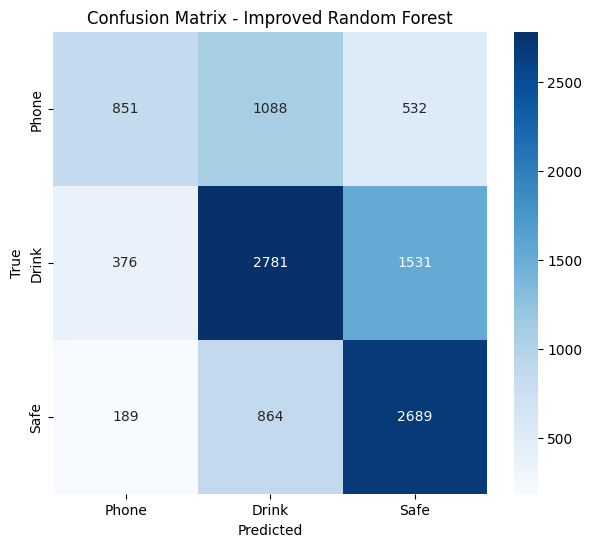

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["Phone", "Drink", "Safe"]

cm = confusion_matrix(y_test, test_pred, labels=labels)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Improved Random Forest")
plt.show()

# Install XGBoost Library

In [44]:
!pip install xgboost -q

# Train an XGBoost Classifier

In [45]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train_enc)
print("Training completed.")

Training XGBoost...
Training completed.


# Evaluate XGBoost Performance on Validation and Test Sets

In [46]:
xgb_val_pred_enc = xgb_model.predict(X_val)
xgb_test_pred_enc = xgb_model.predict(X_test)

xgb_val_pred = label_encoder.inverse_transform(xgb_val_pred_enc)
xgb_test_pred = label_encoder.inverse_transform(xgb_test_pred_enc)

print("XGBoost Validation Accuracy:", accuracy_score(y_val, xgb_val_pred))
print("XGBoost Test Accuracy:", accuracy_score(y_test, xgb_test_pred))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_test_pred))

XGBoost Validation Accuracy: 0.6339459136411176
XGBoost Test Accuracy: 0.5710485276580131

XGBoost Classification Report:
              precision    recall  f1-score   support

       Drink       0.61      0.56      0.58      4688
       Phone       0.54      0.39      0.45      2471
        Safe       0.55      0.71      0.62      3742

    accuracy                           0.57     10901
   macro avg       0.57      0.55      0.55     10901
weighted avg       0.57      0.57      0.57     10901

